In [1]:
#! wget https://stringdb-static.org/download/protein.links.v11.5/9606.protein.links.v11.5.txt.gz && gunzip 9606.protein.links.v11.5.txt.gz
#! wget https://stringdb-static.org/download/protein.links.v11.5/362663.protein.links.v11.5.txt.gz && gunzip 362663.protein.links.v11.5.txt.gz
#! wget https://stringdb-static.org/download/protein.links.v11.5/4932.protein.links.v11.5.txt.gz && gunzip 4932.protein.links.v11.5.txt.gz
#! wget https://stringdb-static.org/download/protein.links.v11.5/10090.protein.links.v11.5.txt.gz && gunzip 10090.protein.links.v11.5.txt.gz

! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:fruit%20fly
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:yeast

--2021-10-06 10:04:51--  http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘species:human.1’

species:human.1         [          <=>       ]  64.46M   628KB/s    in 71s     

2021-10-06 10:06:03 (928 KB/s) - ‘species:human.1’ saved [67592187]

--2021-10-06 10:06:03--  http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘species:mouse.1’

species:mouse.1         [ <=>                ]  14.08M  1.46MB/s    in 11s     

2021-10-06 10:06:15 (1.29 MB/s) -

In [2]:
! pip install networkx
import networkx as nx
import pandas as pd

In [3]:
human_ppi_edges = pd.read_csv("/content/species:human", sep = "\t", header = None)
yeast_ppi_edges = pd.read_csv("/content/species:yeast", sep = "\t", header = None)
fly_ppi_edges = pd.read_csv("/content/species:fruit fly", sep = "\t", header = None)
mouse_ppi_edges = pd.read_csv("/content/species:mouse", sep = "\t", header = None)

In [4]:
human_ppi_nodes = list(set.union(set(human_ppi_edges[0]), set(human_ppi_edges[1])))
yeast_ppi_nodes = list(set.union(set(yeast_ppi_edges[0]), set(yeast_ppi_edges[1])))
fly_ppi_nodes = list(set.union(set(fly_ppi_edges[0]), set(fly_ppi_edges[1])))
mouse_ppi_nodes =  list(set.union(set(mouse_ppi_edges[0]), set(mouse_ppi_edges[1])))

In [5]:
ppi_stats_dict = {"species":["Homo sapiens", "Mus musculus", "Saccharomyces cerevisiae", "Drosophila melanogaster"], 
                  "number of nodes":[len(human_ppi_nodes), len(mouse_ppi_nodes), len(yeast_ppi_nodes), len(fly_ppi_nodes)], 
                  "number of edges":[len(human_ppi_edges), len(mouse_ppi_edges), len(yeast_ppi_edges), len(fly_ppi_edges)]}

In [6]:
pd.DataFrame(ppi_stats_dict)

,species,number of nodes,number of edges
0,Homo sapiens,13367,62772
1,Mus musculus,6780,15160
2,Saccharomyces cerevisiae,4972,42351
3,Drosophila melanogaster,664,986


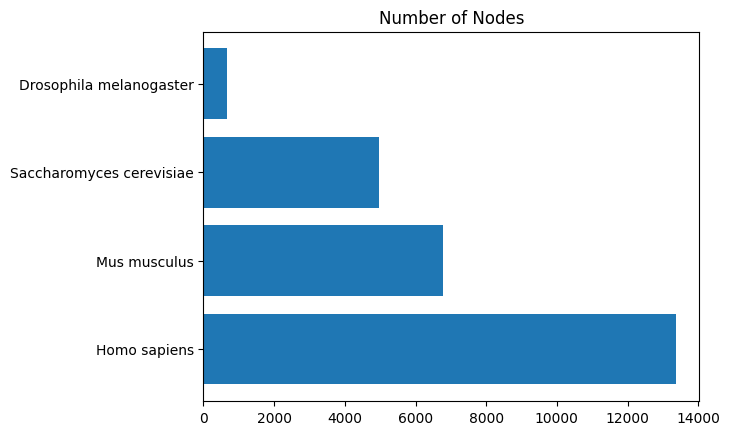

In [7]:
import matplotlib.pyplot as plt
plt.rcdefaults()
fig, ax = plt.subplots()
ax.barh(ppi_stats_dict["species"], ppi_stats_dict["number of nodes"])
plt.title("Number of Nodes")
plt.show()

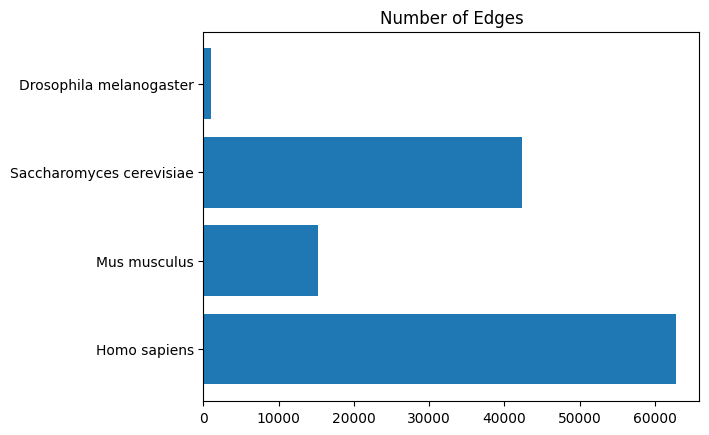

<Figure size 640x480 with 0 Axes>

In [8]:
plt.rcdefaults()
fig, ax = plt.subplots()
ax.barh(ppi_stats_dict["species"], ppi_stats_dict["number of edges"])
plt.title("Number of Edges")
plt.show()
plt.savefig("/Edge_Evo.png")

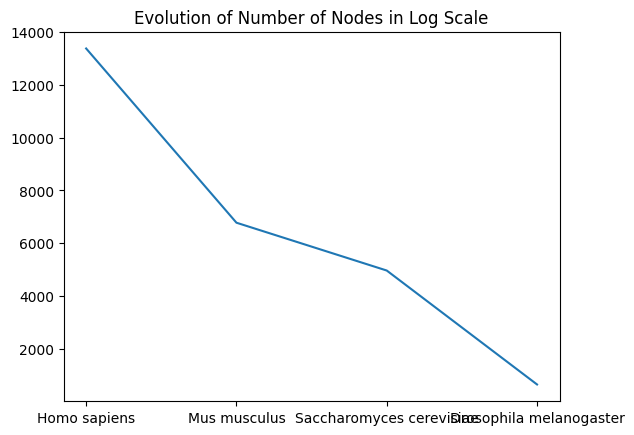

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot([1150, 736, 90, 0], ppi_stats_dict["number of nodes"])
plt.title("Evolution of Number of Nodes in Log Scale")
plt.show()

In [10]:
import pandas as pd
import networkx as nx
def create_graph(edgelist):
  df = edgelist
  g = nx.from_pandas_edgelist(df, source=0, target=1)
  return g

import matplotlib.pyplot as plt
from collections import Counter
def plot_degree_dist(edgelist, title):
  g = create_graph(edgelist)
  degrees = [g.degree(n) for n in g.nodes()]
  counts = Counter(degrees)                                                                                                 
  x, y = zip(*counts.items())

  plt.figure(1)
  plt.title(title)
  plt.xlabel('Degree')
  plt.xscale('log')
  plt.xlim(1, max(x))

  plt.ylabel('Count')
  plt.yscale('log')
  plt.ylim(1, max(x))

  plt.scatter(x,y, marker='o')
  plt.show()

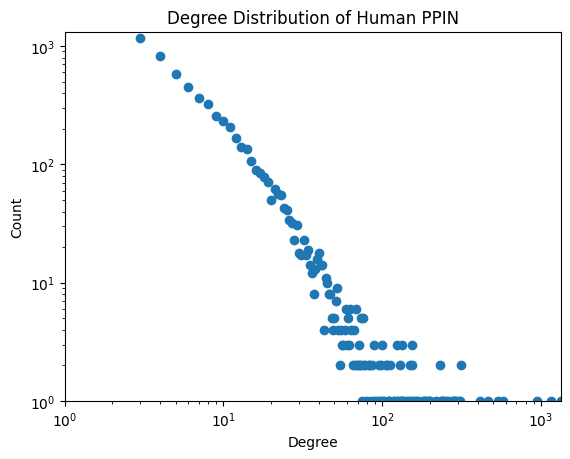

In [11]:
plot_degree_dist(human_ppi_edges, "Degree Distribution of Human PPIN")

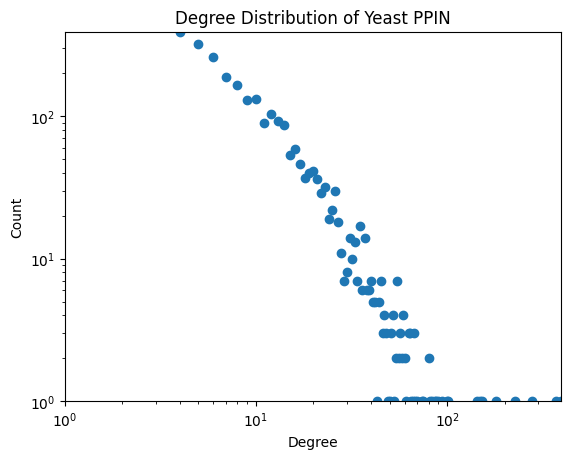

In [12]:
plot_degree_dist(yeast_ppi_edges, "Degree Distribution of Yeast PPIN")

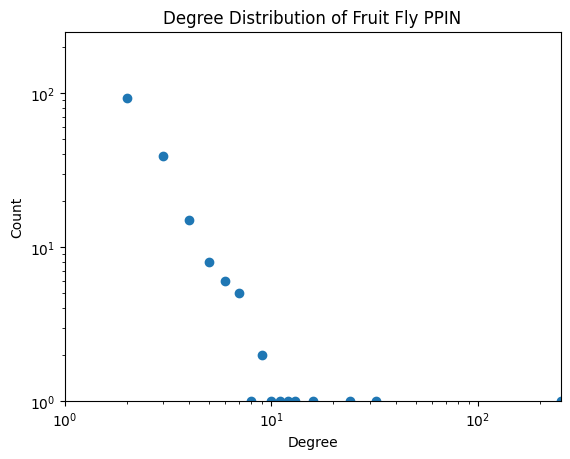

In [13]:
plot_degree_dist(fly_ppi_edges, "Degree Distribution of Fruit Fly PPIN")

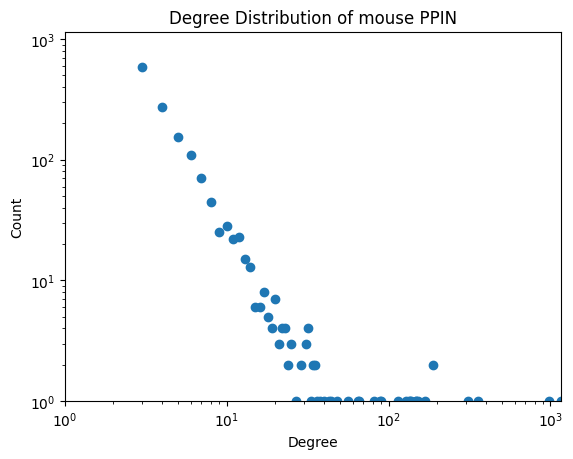

In [14]:
plot_degree_dist(mouse_ppi_edges, "Degree Distribution of mouse PPIN")

In [15]:
! wget http://www.hprd.org/RELEASE9/HPRD_Release9_041310.tar.gz

--2021-10-06 10:08:12--  http://www.hprd.org/RELEASE9/HPRD_Release9_041310.tar.gz
Resolving www.hprd.org (www.hprd.org)... 54.196.163.61
Connecting to www.hprd.org (www.hprd.org)|54.196.163.61|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 687774 (672K) [application/x-tar]
Saving to: ‘HPRD_Release9_041310.tar.gz.1’

HPRD_Release9_04131 100%[===================>] 671.65K  --.-KB/s    in 0.1s    

2021-10-06 10:08:12 (6.64 MB/s) - ‘HPRD_Release9_041310.tar.gz.1’ saved [687774/687774]



In [16]:
!tar -zxvf HPRD_Release9_041310.tar.gz

HPRD_Release9_062910/
HPRD_Release9_062910/BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt
HPRD_Release9_062910/README


In [17]:
! cat HPRD_Release9_062910/BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt | head

ALDH1A1	00001	NP_000680.2	ALDH1A1	00001	NP_000680.2	in vivo;yeast 2-hybrid	12081471,16189514
ITGA7	02761	NP_001138468.1	CHRNA1	00007	NP_001034612.1	in vivo	10910772
PPP1R9A	16000	NP_060120.2	ACTG1	00017	NP_001605.1	in vitro;in vivo	9362513,12052877
SRGN	01513	NP_002718.2	CD44	00115	NP_000601.3	in vivo	9334256
GRB7	03311	NP_005301.2	ERBB2	01281	NP_004439.2	in vitro;in vivo	9079677
PAK1	03995	AAC24716.1	ERBB2	01281	NP_004439.2	in vivo	9774445
DLG4	04199	NP_001356.1	ERBB2	01281	NP_004439.2	in vivo;yeast 2-hybrid	10839362
PIK3R2	04404	NP_005018.1	ERBB2	01281	NP_004439.2	in vivo	1334406
PTPN18	05961	NP_055184.2	ERBB2	01281	NP_004439.2	in vitro	14660651
ERBB2IP	06090	AAK69431.1	ERBB2	01281	NP_004439.2	in vitro;in vivo	11278603,10878805


In [18]:
! cat HPRD_Release9_062910/README


#########################################################################
#                                                                       #
#  Human Protein Reference Database                                     #
#                                                                       #
#  Copyright (C) 2002-09, Johns Hopkins University and                  #
#                         The Institute of Bioinformatics.              #
#                                                                       #
#  This code is licensed under the GNU Lesser General Public License.   #
#  See the file LICENSE or this URL for the full text of the license:   #
#  http://www.gnu.org/licenses/lgpl.html                                #
#                                                                       #
#########################################################################

Number of files = 1
1. BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt

This file stores all the binary protein protei

In [19]:
human_ppi_edges1 = pd.read_csv("HPRD_Release9_062910/BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt", sep = "\t", header=None)

In [20]:
human_ppi_edges1[[0,3]]

,0,3
0,ALDH1A1,ALDH1A1
1,ITGA7,CHRNA1
2,PPP1R9A,ACTG1
3,SRGN,CD44
4,GRB7,ERBB2
...,...,...
39235,SHC1,ERBB2
39236,IL6ST,ERBB2
39237,PTK2,ERBB2
39238,CAV1,ERBB2


In [23]:
# plot_degree_dist(human_ppi_edges1[[0,3]], "Degree Distribution of Human PPIN (HPRD)")

In [24]:
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:fruit%20fly
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:yeast

--2021-10-06 10:16:06--  http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘species:human.2’

species:human.2         [       <=>          ]  28.29M   324KB/s               ^C
--2021-10-06 10:17:25--  http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘species:mouse.2’

species:mouse.2         [               <=>  ]  14.08M   340KB/s    in 56s     

2021-10-06 10:18:22 (260 KB/s) - ‘species:mouse.2’ saved [14767741]

--2021-10-06 10:18:22--  http://

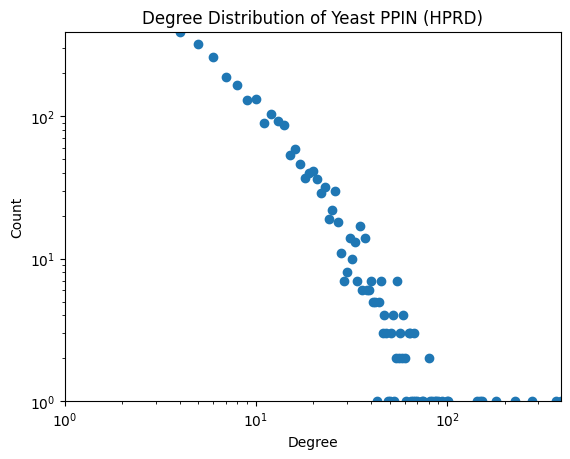

In [25]:
plot_degree_dist(pd.read_csv("/content/species:yeast",sep="\t", header = None)[[0,1]], "Degree Distribution of Yeast PPIN (HPRD)")

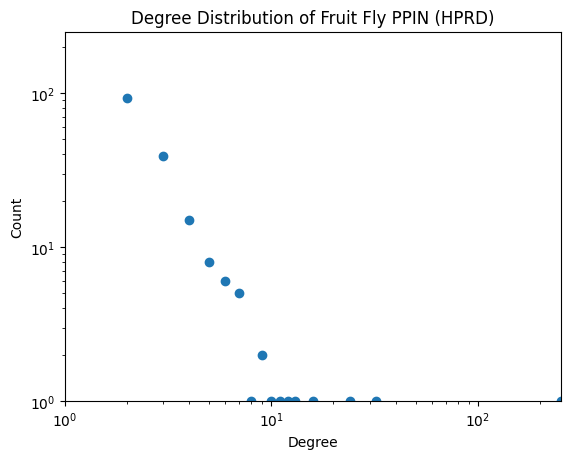

In [26]:
plot_degree_dist(pd.read_csv("/content/species:fruit fly",sep="\t", header = None)[[0,1]], "Degree Distribution of Fruit Fly PPIN (HPRD)")

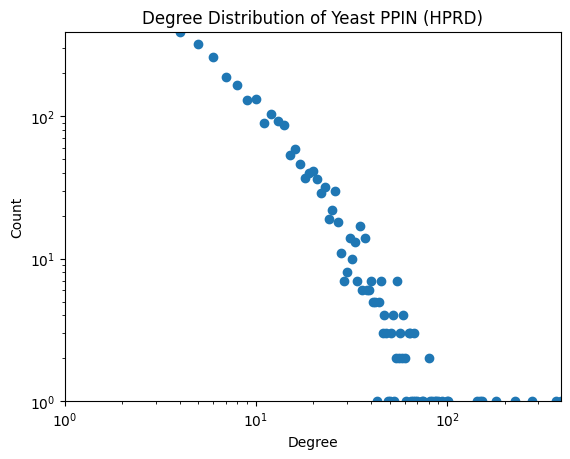

In [27]:
plot_degree_dist(pd.read_csv("/content/species:yeast",sep="\t", header = None)[[0,1]], "Degree Distribution of Yeast PPIN (HPRD)")

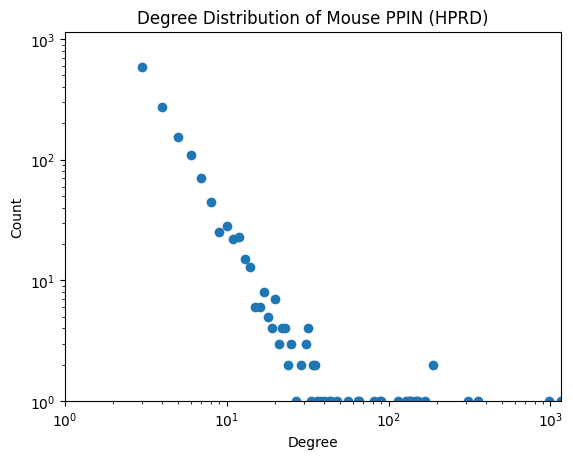

In [28]:
plot_degree_dist(pd.read_csv("/content/species:mouse",sep="\t", header = None)[[0,1]], "Degree Distribution of Mouse PPIN (HPRD)")

In [29]:
import networkx as nx
human_ppi = nx.from_pandas_edgelist(human_ppi_edges, 0, 1) #, ["combined_score"])
# Do not use combined_score. They are not weight! See https://string-db.org/cgi/info
nx.info(human_ppi)
yeast_ppi = nx.from_pandas_edgelist(yeast_ppi_edges, 0, 1) #, ["combined_score"])
nx.info(yeast_ppi)

'Graph with 4972 nodes and 19545 edges'

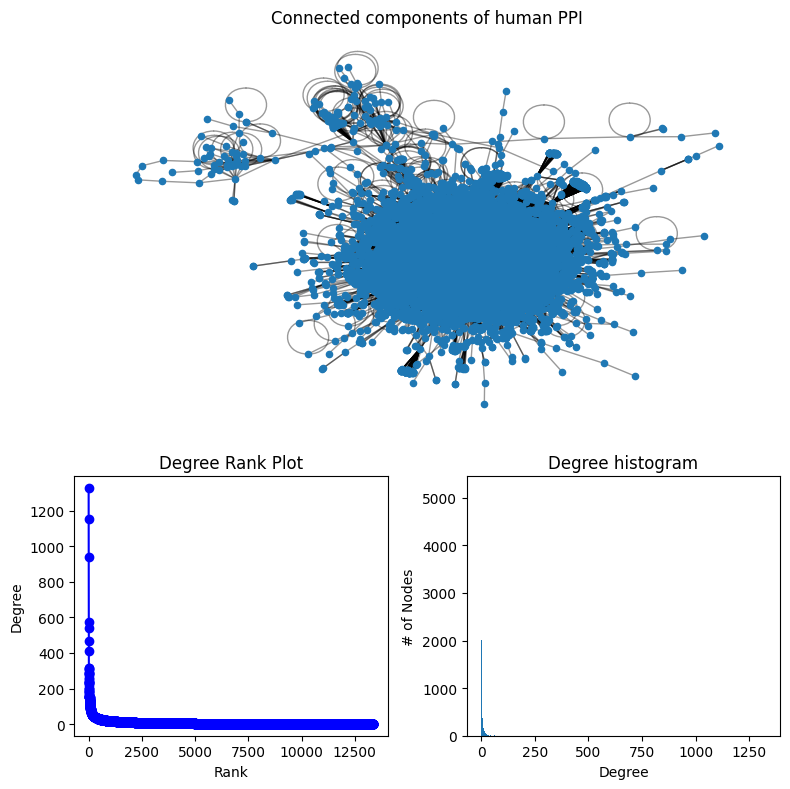

In [30]:
import matplotlib.pyplot as plt
import numpy as np

human_degree_sequence = sorted([d for n, d in human_ppi.degree()], reverse=True)
human_dmax = max(human_degree_sequence)

fig = plt.figure("Degree of human PPI", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = human_ppi.subgraph(sorted(nx.connected_components(human_ppi), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Connected components of human PPI")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(human_degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(human_degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.tight_layout()
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:26: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


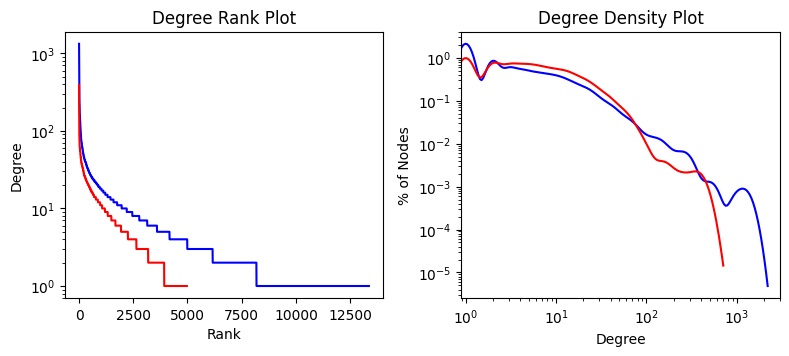

In [93]:
yeast_degree_sequence = sorted([d for n, d in yeast_ppi.degree()], reverse=True)
yeast_dmax = max(yeast_degree_sequence)

fig = plt.figure("Degree of yeast PPI", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(human_degree_sequence, "blue")
ax1.plot(yeast_degree_sequence, "red")
ax1.set_title("Degree Rank Plot")
ax1.set_yscale("log")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")


ax2 = fig.add_subplot(axgrid[3:, 2:])
#ax2.barh(*np.unique(human_degree_sequence, return_counts=True), color="blue")
#ax2.barh(*np.unique(yeast_degree_sequence, return_counts=True), color="red")
ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_title("Degree Density Plot")
ax2.set_xlabel("Degree")
ax2.set_ylabel("% of Nodes")
plt.xlim([0,3000])
import seaborn as sns
sns.distplot(human_degree_sequence, hist=False, color="blue")
sns.distplot(yeast_degree_sequence, hist=False, color="red")


fig.tight_layout()
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


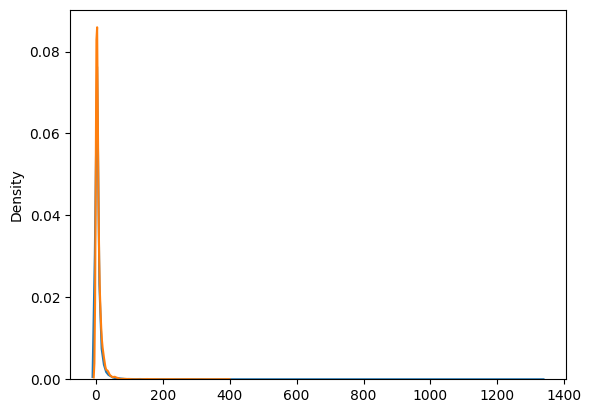

In [32]:
# https://snap.stanford.edu/snappy
#! pip install snap-stanford
#! sudo apt install graphviz gnuplot
import pandas as pd

human_ppi_edges = pd.read_csv("/content/species:human", sep = "\t", header = None)
yeast_ppi_edges = pd.read_csv("/content/species:yeast", sep = "\t", header = None)
fly_ppi_edges = pd.read_csv("/content/species:fruit fly", sep = "\t", header = None)
mouse_ppi_edges = pd.read_csv("/content/species:mouse", sep = "\t", header = None)

human_ppi_edges[[0,1]].rename(columns={0: "protein1", 1: "protein2"}).to_csv("/content/drive/MyDrive/Network_GroupProject/MINT_human_ppi_edges2.csv", index = False)
yeast_ppi_edges[[0,1]].rename(columns={0: "protein1", 1: "protein2"}).to_csv("/content/drive/MyDrive/Network_GroupProject/MINT_yeast_ppi_edges2.csv", index = False)

In [33]:
pd.read_csv("/content/drive/MyDrive/Network_GroupProject/MINT_human_ppi_edges2.csv")

,protein1,protein2
0,uniprotkb:Q72547,uniprotkb:Q72547
1,uniprotkb:Q72547,uniprotkb:Q72547
2,uniprotkb:Q72547,uniprotkb:Q72547
3,uniprotkb:Q90VU7,uniprotkb:Q900A7
4,uniprotkb:Q4ZGA4,uniprotkb:Q12959
...,...,...
62767,uniprotkb:Q83DE4,uniprotkb:Q96PY5
62768,uniprotkb:Q83DE4,uniprotkb:Q03112
62769,uniprotkb:Q83DE4,uniprotkb:O14786
62770,uniprotkb:P0CK48,uniprotkb:A6SZC0


In [34]:
def nodelist(edge_list):
  return list(set.union(set(edge_list["protein1"]), set(edge_list["protein2"])))

In [35]:
human_ppi_edges = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/MINT_human_ppi_edges2.csv")
human_ppi_nodes = nodelist(human_ppi_edges)

yeast_ppi_edges = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/MINT_yeast_ppi_edges2.csv")
yeast_ppi_nodes = nodelist(yeast_ppi_edges)

In [36]:
yeast_ppi_nodes = [i[10:] for i in yeast_ppi_nodes]
human_ppi_nodes = [i[10:] for i in human_ppi_nodes]

In [37]:
! pip install gprofiler-official
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
orth = gp.orth(organism='scerevisiae',
            query=yeast_ppi_nodes,
            target='hsapiens')

In [38]:
query_list = list(set(orth[["ortholog_ensg"]].transpose().to_numpy().tolist()[0]))
yeast_to_human = gp.convert(organism='hsapiens',query=query_list,target_namespace='UNIPROTSWISSPROT_ACC')

In [39]:
yeast_to_human_orth = orth[["incoming",'ortholog_ensg']].set_index('ortholog_ensg').join(yeast_to_human[["incoming","converted"]].set_index('incoming'))
yeast_to_human_orth

,incoming,converted
ENSG00000000419,P14020,O60762
ENSG00000001167,P06774,P23511
ENSG00000001561,P39997,Q9Y6X5
ENSG00000001630,P10614,Q16850
ENSG00000002016,P06778,P43351
...,...,...
N/A,P38804,nan
N/A,P15703,nan
N/A,Q12027,nan
N/A,Q04087,nan


In [40]:
yeast_conserved = yeast_to_human_orth.drop_duplicates("converted")["incoming"].to_numpy().tolist()
yeast_specific = [node for node in yeast_to_human_orth.drop_duplicates("incoming")["incoming"] if (node not in yeast_conserved)]      

In [41]:
human_conserved_mapped = set(yeast_to_human_orth.drop_duplicates("converted")["converted"].to_numpy().tolist())
human_conserved = [protein for protein in human_conserved_mapped if protein in human_ppi_nodes]
human_specific = [protein for protein in human_ppi_nodes if protein not in human_conserved]

In [42]:
len(human_conserved_mapped)

3295

In [43]:
len(human_conserved) - len(human_ppi_nodes)

-11151

In [44]:
len(yeast_specific)
yeast_conserved

['P14020',
 'P06774',
 'P39997',
 'P10614',
 'P06778',
 'P21827',
 'P47147',
 'P48813',
 'P32566',
 'P07170',
 'P32472',
 'P32463',
 'P53170',
 'P25297',
 'P33311',
 'P38042',
 'P30771',
 'P36009',
 'P07213',
 'P36152',
 'P53600',
 'Q12432',
 'P07834',
 'P33311',
 'P42948',
 'P24814',
 'P53170',
 'P35844',
 'P46682',
 'P47771',
 'P51862',
 'P32325',
 'P38959',
 'P36159',
 'P39946',
 'Q06116',
 'P39535',
 'Q99394',
 'P23254',
 'Q07508',
 'Q08748',
 'Q12094',
 'P53306',
 'P18412',
 'Q08908',
 'P23724',
 'P32622',
 'P47102',
 'P39526',
 'P21825',
 'P38701',
 'P53119',
 'P31382',
 'P40989',
 'P35817',
 'P53076',
 'P07257',
 'P53154',
 'Q06156',
 'P36010',
 'P11325',
 'P53043',
 'P06838',
 'P39540',
 'P47156',
 'P34216',
 'P33298',
 'P22855',
 'P48813',
 'P22276',
 'P31384',
 'P22516',
 'P38121',
 'P47147',
 'P40086',
 'P13586',
 'P38176',
 'P38778',
 'P13586',
 'P42842',
 'Q03290',
 'Q08831',
 'P32829',
 'P48813',
 'P40328',
 'P35844',
 'P43560',
 'P25373',
 'P39109',
 'P19812',
 'P34216',

In [45]:
path_prefix = "/content/drive/MyDrive/Network_GroupProject/new_Data/"

def list_to_txt(mylist, location):
  textfile = open(location, "w")
  for line in mylist:
    textfile.write(line + "\n")
  textfile.close()

list_to_txt(human_conserved, path_prefix+"human_conserved.txt")
list_to_txt(human_specific, path_prefix+"human_specific.txt")
list_to_txt(yeast_conserved, path_prefix+"yeast_conserved.txt")
list_to_txt(yeast_specific, path_prefix+"yeast_specific.txt")

list_to_txt(yeast_ppi_nodes, path_prefix+"human_all.txt")
list_to_txt(human_ppi_nodes, path_prefix+"yeast_all.txt")

In [46]:
def neig(node, net):
  return set([n for n in net.neighbors(node)])

def neig_count(node1, node2, net):
  node1_neig = neig(node1, net)
  node2_neig = neig(node2, net)
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  return len(node1_neig), len(node2_neig), len(intersec_neig)

def intersec_neig(node1, node2, net):
  node1_neig = set([n for n in net.neighbors(node1)])
  node2_neig = set([n for n in net.neighbors(node2)])
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  return intersec_neig

# Adjusted CD Distance
def adj_CD(node1, node2, net, avg_degree):
  # avg_degree = sum(pd.DataFrame(net.degree())[1])/len(pd.DataFrame(net.degree())[0])
  node1_neig = set([n for n in net.neighbors(node1)])
  node2_neig = set([n for n in net.neighbors(node2)])
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  lambdaU = max(0, avg_degree-len(node1_neig))
  lambdaV = max(0, avg_degree-len(node2_neig))
  distance = 2*len(intersec_neig)/(len(node1_neig)+len(node2_neig)+lambdaU+lambdaV)
  return distance

# neig_count("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi)
# intersec_neig("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi)

In [47]:
# for the use of progress bar, please read https://zhuanlan.zhihu.com/p/403641309
!pip install tqdm
from tqdm.notebook import tqdm 
tqdm.pandas(desc="How stupid this script is!")

# Let's make this simpler: just get the CD distance of the edge list
human_avg_degree = sum(pd.DataFrame(human_ppi.degree())[1])/len(pd.DataFrame(human_ppi.degree())[0])
human_node_num = len(human_ppi_nodes)
human_ppi_edges["CD_distance"] = human_ppi_edges.progress_apply(lambda row: adj_CD(row["protein1"], row["protein2"], human_ppi, human_avg_degree), axis = 1)

yeast_avg_degree = sum(pd.DataFrame(yeast_ppi.degree())[1])/len(pd.DataFrame(yeast_ppi.degree())[0])
yeast_node_num = len(yeast_ppi_nodes)
yeast_ppi_edges["CD_distance"] = yeast_ppi_edges.progress_apply(lambda row: adj_CD(row["protein1"], row["protein2"], yeast_ppi, yeast_avg_degree), axis = 1)

How stupid this script is!:   0%|          | 0/62772 [00:00<?, ?it/s]

How stupid this script is!:   0%|          | 0/42351 [00:00<?, ?it/s]

In [94]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
gp.profile(organism='hsapiens',
            query=human_specific)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:MF,GO:0005515,protein binding,3.474362e-260,True,"""Interacting selectively and non-covalently wi...",14767,7180,6567,18679,0.914624,0.444708,query_1,[GO:0005488]
1,GO:CC,GO:0005622,intracellular anatomical structure,3.128062e-184,True,"""A component of a cell contained within (but n...",14808,7152,6359,18964,0.889122,0.429430,query_1,[GO:0110165]
2,GO:CC,GO:0043226,organelle,1.991834e-171,True,"""Organized structure of distinctive morphology...",14027,7152,6090,18964,0.851510,0.434163,query_1,[GO:0110165]
3,GO:CC,GO:0043229,intracellular organelle,2.942469e-171,True,"""Organized structure of distinctive morphology...",13117,7152,5794,18964,0.810123,0.441717,query_1,"[GO:0005622, GO:0043226]"
4,GO:CC,GO:0043227,membrane-bounded organelle,4.017497e-139,True,"""Organized structure of distinctive morphology...",13201,7152,5741,18964,0.802713,0.434891,query_1,[GO:0043226]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3683,GO:BP,GO:0019935,cyclic-nucleotide-mediated signaling,4.871687e-02,True,"""Any intracellular signal transduction in whic...",96,6951,57,18123,0.008200,0.593750,query_1,[GO:0019932]
3684,HP,HP:0008775,Abnormal prostate morphology,4.934006e-02,True,An abnormality of the prostate.,38,2224,31,4511,0.013939,0.815789,query_1,[HP:0000022]
3685,MIRNA,MIRNA:hsa-miR-6825-5p,hsa-miR-6825-5p,4.969097e-02,True,hsa-miR-6825-5p,380,6442,203,14823,0.031512,0.534211,query_1,[MIRNA:000000]
3686,GO:MF,GO:0043495,protein-membrane adaptor activity,4.976349e-02,True,"""The binding activity of a molecule that bring...",23,7180,18,18679,0.002507,0.782609,query_1,[GO:0030674]


In [99]:
# ! pip install gseapy
import gseapy
gseapy.enrichr(gene_list=human_specific, description='pathway', gene_sets='KEGG_2016')

2021-10-06 11:18:04,448 Warning: No enrich terms using library KEGG_2016 when cutoff = 0.05
